# Notebook 2 — Data Enhancement

Demonstrates and validates the preprocessing + augmentation pipeline:
deskew → denoise → binarize → morphology, plus augmentation preview
and line-segmentation quality analysis.


## 1. Setup


In [2]:
%matplotlib inline
import os, sys, random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import torchvision.transforms as T

sys.path.insert(0, os.path.abspath('..'))
ROOT = os.path.abspath('..')
IMAGES_DIR = os.path.join(ROOT, 'data', 'raw', 'images')

try:
    from src.preprocess import preprocess_image, segment_lines, deskew
    print('Loaded preprocessing functions from src.preprocess')
except Exception as e:
    print(f'[WARN] Could not import from src.preprocess: {e}')
    # ---- inline fallbacks ----
    def deskew(pil_img):
        arr = np.array(pil_img.convert('L'))
        edges = cv2.Canny(arr, 50, 200, apertureSize=3)
        lines = cv2.HoughLinesP(edges, 1, np.pi / 180, 100, minLineLength=50, maxLineGap=10)
        if lines is None:
            return pil_img
        angles = [np.degrees(np.arctan2(y2 - y1, x2 - x1)) for x1, y1, x2, y2 in lines[:, 0]]
        median = np.median(angles)
        if abs(median) < 0.5:
            return pil_img
        h, w = arr.shape
        M = cv2.getRotationMatrix2D((w // 2, h // 2), median, 1.0)
        rotated = cv2.warpAffine(np.array(pil_img.convert('RGB')), M, (w, h),
                                 borderMode=cv2.BORDER_REPLICATE)
        return Image.fromarray(rotated)

    def preprocess_image(pil_img):
        rgb = np.array(pil_img.convert('RGB'))
        gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
        deskewed = np.array(deskew(pil_img).convert('RGB'))
        gray_d = cv2.cvtColor(deskewed, cv2.COLOR_RGB2GRAY)
        denoised = cv2.fastNlMeansDenoising(gray_d, None, 14, 7, 21)
        thresh = cv2.adaptiveThreshold(denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                       cv2.THRESH_BINARY, 31, 10)
        kernel = np.ones((2, 2), np.uint8)
        opened = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
        return Image.fromarray(cv2.cvtColor(
            cv2.merge([opened, opened, opened]), cv2.COLOR_BGR2RGB))

    def segment_lines(pil_img, min_height=15):
        gray = np.array(pil_img.convert('L'))
        _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        h_proj = np.sum(binary, axis=1)
        lines, in_line, start = [], False, 0
        for y, val in enumerate(h_proj):
            if val > 0 and not in_line:
                in_line, start = True, y
            elif val == 0 and in_line:
                if y - start >= min_height:
                    lines.append(pil_img.crop((0, start, pil_img.width, y)))
                in_line = False
        if in_line and pil_img.height - start >= min_height:
            lines.append(pil_img.crop((0, start, pil_img.width, pil_img.height)))
        return lines if lines else [pil_img]

random.seed(42)
print(f'Images dir: {IMAGES_DIR}')


[WARN] Could not import from src.preprocess: cannot import name 'preprocess_image' from 'src.preprocess' (/home/lokmane/Desktop/Medical_Prescription_OCR/src/preprocess.py)
Images dir: /home/lokmane/Desktop/Medical_Prescription_OCR/data/raw/images


## 2. Load Sample Batch


In [3]:
all_images = sorted(f for f in os.listdir(IMAGES_DIR) if f.lower().endswith('.png'))
sample_names = random.sample(all_images, min(8, len(all_images)))
sample_paths = [os.path.join(IMAGES_DIR, s) for s in sample_names]
print(f'Total images: {len(all_images)}, sampled: {len(sample_paths)}')


Total images: 1000, sampled: 8


## 3. Step-by-Step Preprocessing (Single Image)

Shows every stage of the pipeline side-by-side so we can debug
thresholding, denoising, and morphology parameters.


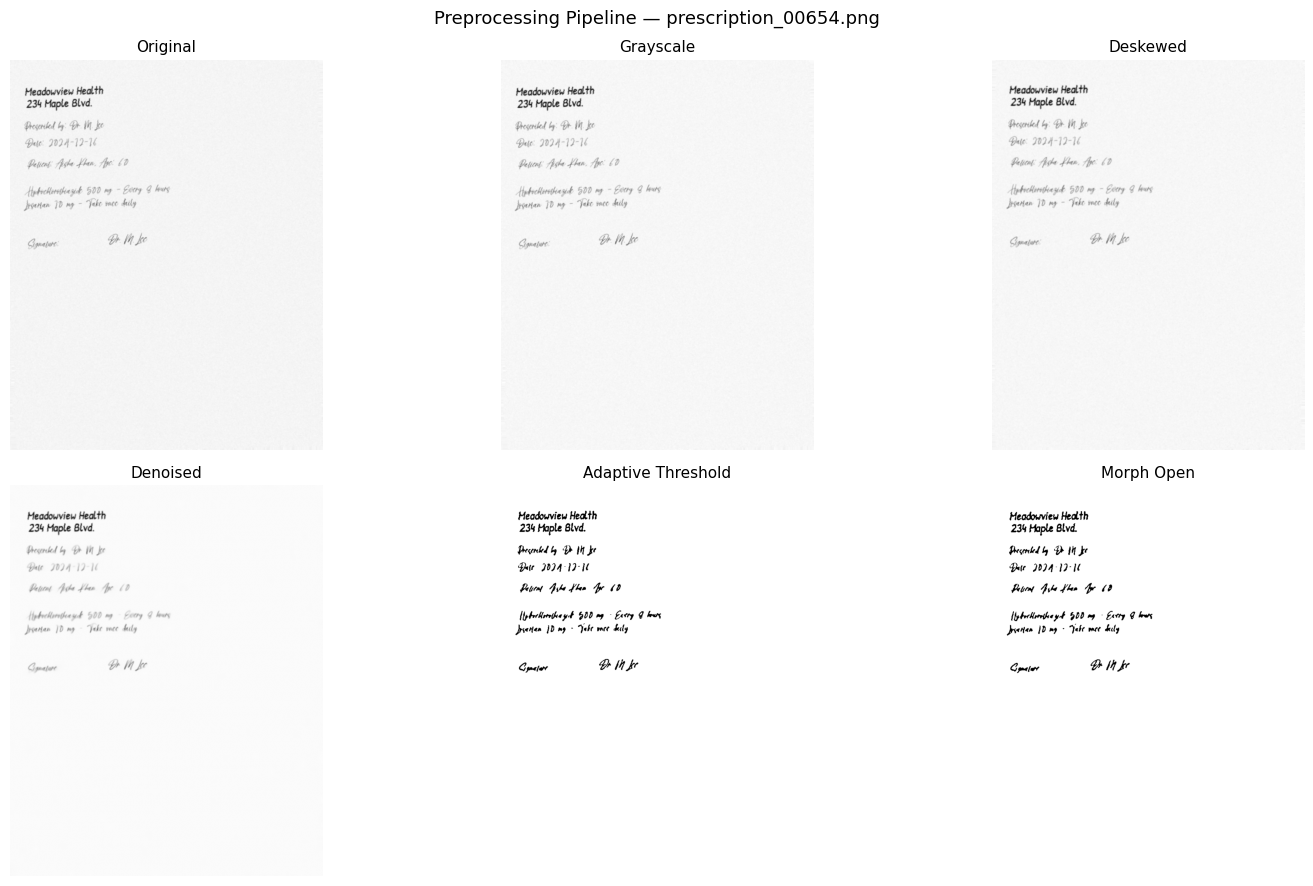

In [4]:
one_path = sample_paths[0]
rgb_pil = Image.open(one_path).convert('RGB')
rgb = np.array(rgb_pil)
gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)

deskewed_pil = deskew(rgb_pil)
deskewed_gray = cv2.cvtColor(np.array(deskewed_pil.convert('RGB')), cv2.COLOR_RGB2GRAY)

denoised = cv2.fastNlMeansDenoising(deskewed_gray, None, 14, 7, 21)
thresholded = cv2.adaptiveThreshold(denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                    cv2.THRESH_BINARY, 31, 10)
kernel = np.ones((2, 2), np.uint8)
opened = cv2.morphologyEx(thresholded, cv2.MORPH_OPEN, kernel)

stages = [
    ('Original', rgb),
    ('Grayscale', gray),
    ('Deskewed', deskewed_gray),
    ('Denoised', denoised),
    ('Adaptive Threshold', thresholded),
    ('Morph Open', opened),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (title, img) in zip(axes.flatten(), stages):
    cmap = 'gray' if img.ndim == 2 else None
    ax.imshow(img, cmap=cmap)
    ax.set_title(title, fontsize=11)
    ax.axis('off')
plt.suptitle(f'Preprocessing Pipeline — {os.path.basename(one_path)}', fontsize=13)
plt.tight_layout()
plt.show()


## 4. Pixel Intensity Histograms (Before vs After)

Quantitative check: preprocessing should sharpen the bimodal distribution
(background vs ink), making OCR easier.


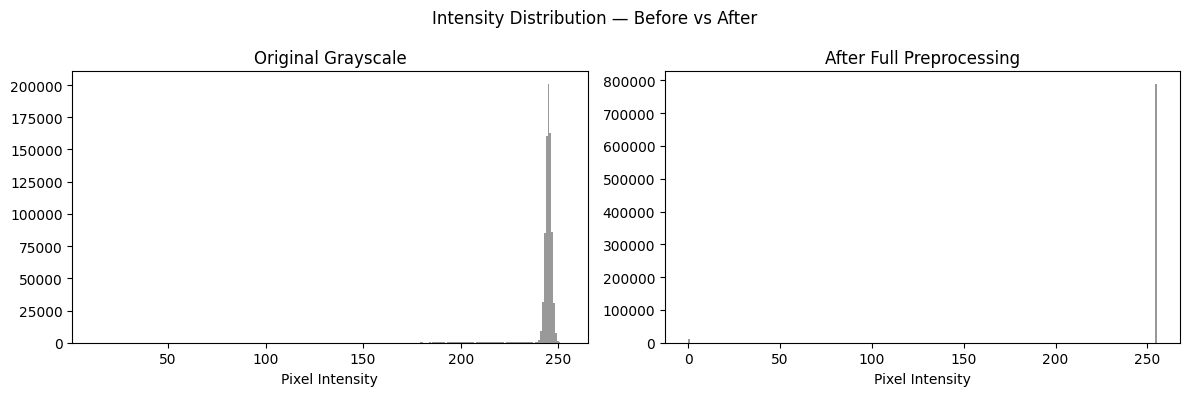

Dark-pixel ratio: 0.003 (before) → 0.015 (after)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(gray.ravel(), bins=256, color='gray', alpha=0.8)
axes[0].set_title('Original Grayscale')
axes[0].set_xlabel('Pixel Intensity')

axes[1].hist(opened.ravel(), bins=256, color='gray', alpha=0.8)
axes[1].set_title('After Full Preprocessing')
axes[1].set_xlabel('Pixel Intensity')

plt.suptitle('Intensity Distribution — Before vs After', fontsize=12)
plt.tight_layout()
plt.show()

ink_ratio_before = np.mean(gray < 128)
ink_ratio_after = np.mean(opened < 128)
print(f'Dark-pixel ratio: {ink_ratio_before:.3f} (before) → {ink_ratio_after:.3f} (after)')


## 5. Before / After Grid (6 Images)


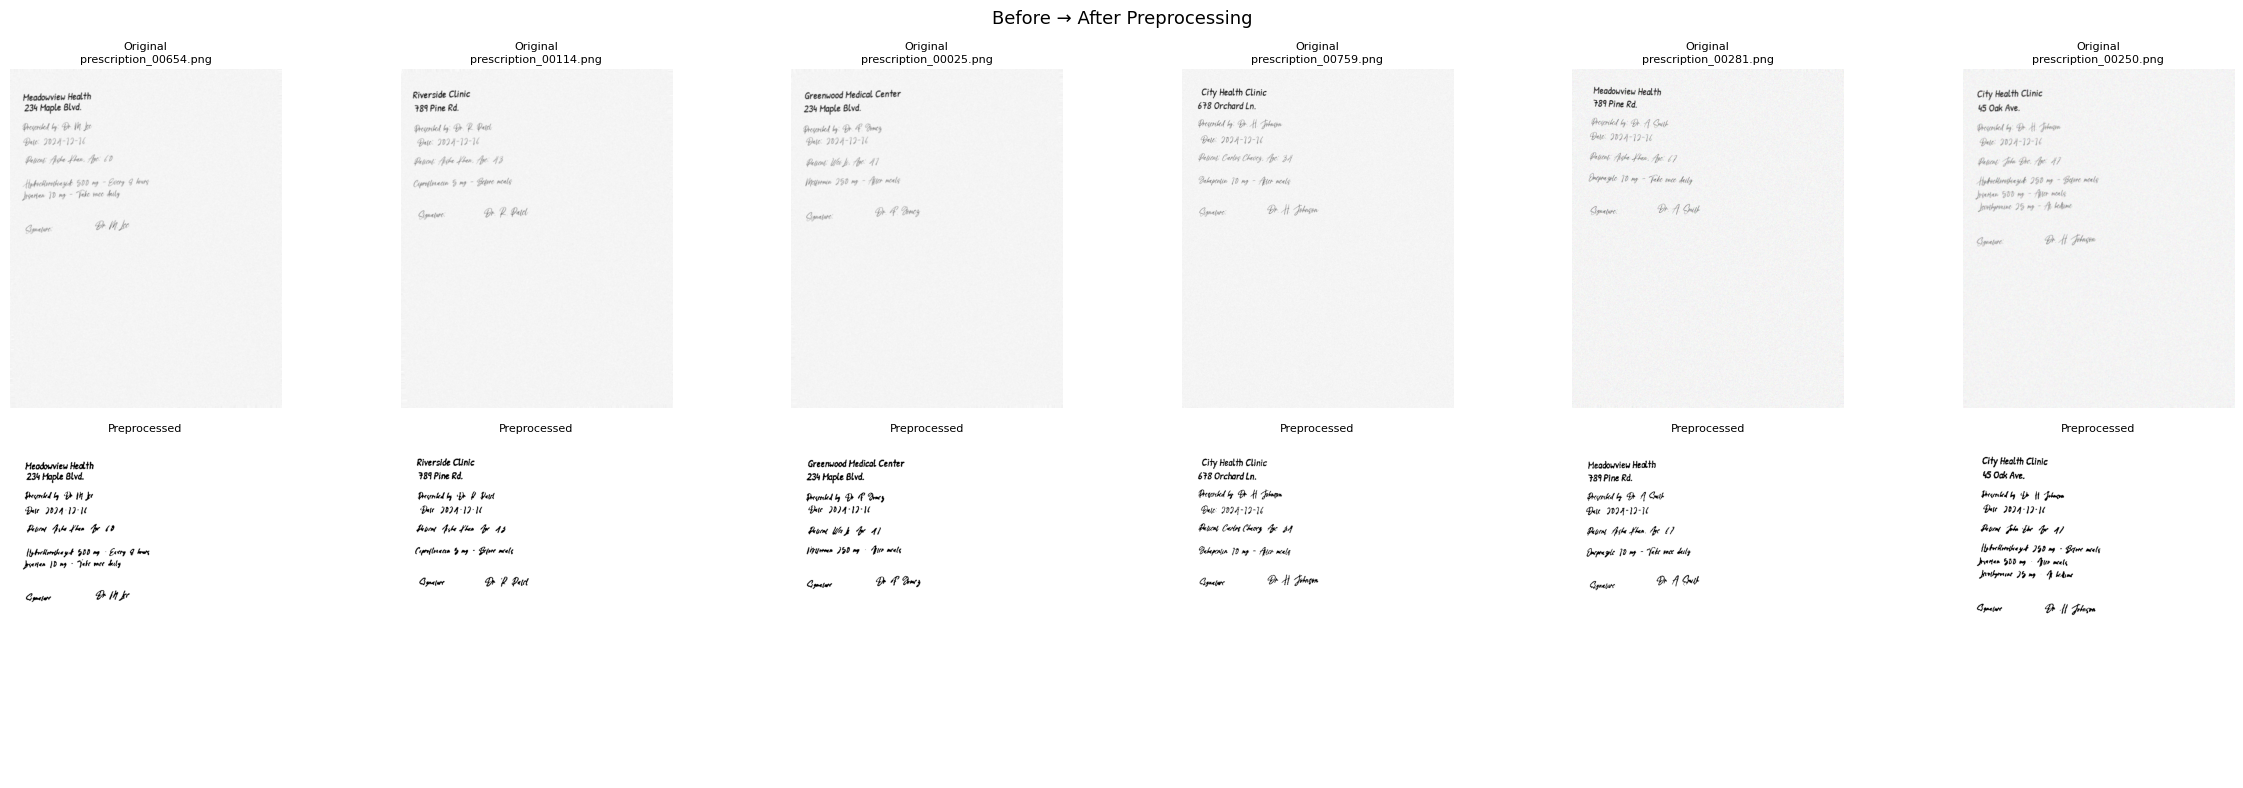

In [6]:
show_paths = sample_paths[:6]
fig, axes = plt.subplots(2, len(show_paths), figsize=(4 * len(show_paths), 8))

for col, path in enumerate(show_paths):
    original = Image.open(path).convert('RGB')
    enhanced = preprocess_image(original)
    axes[0, col].imshow(np.array(original))
    axes[0, col].set_title(f'Original\n{os.path.basename(path)}', fontsize=8)
    axes[0, col].axis('off')
    axes[1, col].imshow(np.array(enhanced))
    axes[1, col].set_title('Preprocessed', fontsize=8)
    axes[1, col].axis('off')

plt.suptitle('Before → After Preprocessing', fontsize=13)
plt.tight_layout()
plt.show()


## 6. Augmentation Preview


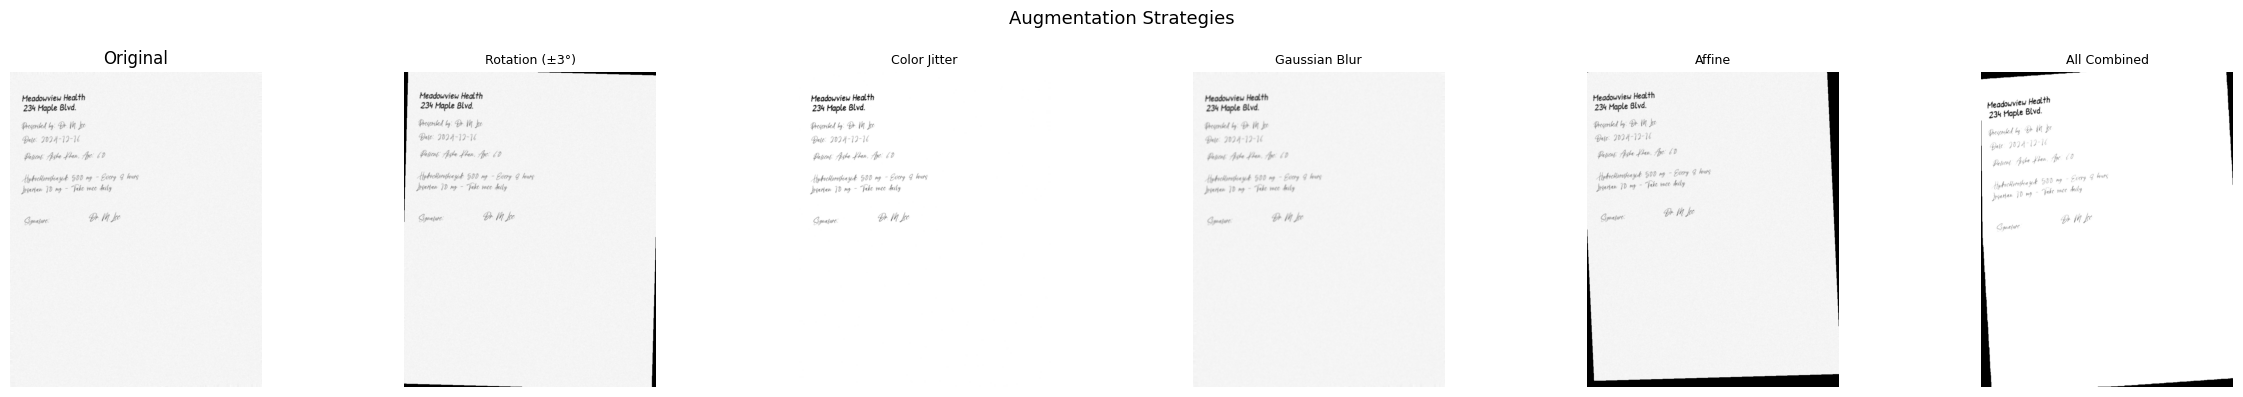

In [7]:
base_img = Image.open(sample_paths[0]).convert('RGB')

augmentations = {
    'Rotation (±3°)': T.RandomRotation(degrees=3),
    'Color Jitter': T.ColorJitter(brightness=0.2, contrast=0.2),
    'Gaussian Blur': T.GaussianBlur(kernel_size=5, sigma=(0.1, 1.5)),
    'Affine': T.RandomAffine(degrees=3, translate=(0.02, 0.02),
                              scale=(0.98, 1.02), shear=2),
    'All Combined': T.Compose([
        T.RandomRotation(degrees=3),
        T.ColorJitter(brightness=0.2, contrast=0.2),
        T.GaussianBlur(kernel_size=5, sigma=(0.1, 1.5)),
        T.RandomAffine(degrees=3, translate=(0.02, 0.02),
                        scale=(0.98, 1.02), shear=2),
    ]),
}

fig, axes = plt.subplots(1, 1 + len(augmentations), figsize=(4 * (1 + len(augmentations)), 4))
axes[0].imshow(np.array(base_img))
axes[0].set_title('Original')
axes[0].axis('off')

for i, (name, tfm) in enumerate(augmentations.items(), 1):
    axes[i].imshow(np.array(tfm(base_img)))
    axes[i].set_title(name, fontsize=9)
    axes[i].axis('off')

plt.suptitle('Augmentation Strategies', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Split Lines + Generate Line Annotations

Split every prescription into line images and save them under
`data/splits/images/<image_stem>/line_XXX.png`.

At the same time, generate aligned annotation text files under
`data/splits/annotations/<image_stem>/line_XXX.txt` using each image's
raw annotation JSON and the fixed line order: clinic_name, clinic_address,
doctor_name, date, patient_name+patient_age, medications, signature.

In [3]:
import json
import re

SPLITS_DIR = os.path.join(ROOT, 'data', 'splits', 'images')
SPLITS_ANN_DIR = os.path.join(ROOT, 'data', 'splits', 'annotations')
RAW_ANN_DIR = os.path.join(ROOT, 'data', 'raw', 'annotations')

os.makedirs(SPLITS_DIR, exist_ok=True)
os.makedirs(SPLITS_ANN_DIR, exist_ok=True)


def parse_ground_truth(gt_string):
    """Parse a raw <s_ocr> ... </s> annotation string into structured fields."""
    inner = re.sub(r'<s_ocr>\s*', '', gt_string or '')
    inner = re.sub(r'\s*</s>', '', inner).strip()

    if not inner:
        return {}

    parsed = {}
    known_keys = (
        'clinic_name|clinic_address|doctor_name|date|'
        'patient_name|patient_age|medications|signature'
    )

    pattern = re.compile(
        rf'({known_keys})\s*:\s*(.*?)(?=\s*(?:{known_keys})\s*:|$)',
        re.IGNORECASE | re.DOTALL,
    )
    for match in pattern.finditer(inner):
        key = match.group(1).lower()
        value = re.sub(r'\s+', ' ', match.group(2)).strip()
        parsed[key] = value

    meds_block = parsed.get('medications', '')
    meds = []
    if meds_block:
        parts = [p.strip() for p in re.split(r'\s*-\s+', meds_block) if p.strip()]
        i = 0
        while i + 1 < len(parts):
            meds.append(f"{parts[i]} - {parts[i + 1]}")
            i += 2
        if i < len(parts):
            meds.append(parts[i])
    parsed['medication_lines'] = meds

    return parsed


def build_line_annotations(raw_gt, n_lines):
    """Create one annotation string per segmented line using fixed field order."""
    parsed = parse_ground_truth(raw_gt)
    if not parsed:
        return ['<s_ocr> unknown: </s>' for _ in range(n_lines)]

    patient_line = f"{parsed.get('patient_name', '').strip()} Age: {parsed.get('patient_age', '').strip()}".strip()
    medication_lines = parsed.get('medication_lines', [])

    sequence = [
        f"<s_ocr> clinic_name: {parsed.get('clinic_name', '')} </s>",
        f"<s_ocr> clinic_address: {parsed.get('clinic_address', '')} </s>",
        f"<s_ocr> doctor_name: {parsed.get('doctor_name', '')} </s>",
        f"<s_ocr> date: {parsed.get('date', '')} </s>",
        f"<s_ocr> patient: {patient_line} </s>",
    ]
    sequence.extend([f"<s_ocr> medications: {m} </s>" for m in medication_lines])
    sequence.append(f"<s_ocr> signature: {parsed.get('signature', '')} </s>")

    if n_lines <= len(sequence):
        annotations = sequence[:n_lines]
        if n_lines >= 2:
            annotations[-1] = sequence[-1]
        return annotations

    padding = ['<s_ocr> unknown: </s>' for _ in range(n_lines - len(sequence))]
    return sequence + padding


saved_lines = 0
saved_annotations = 0
failed_images = []
line_counts = []
missing_annotations = []

for fname in tqdm(all_images, desc='Splitting lines + annotations'):
    img_path = os.path.join(IMAGES_DIR, fname)
    stem = os.path.splitext(fname)[0]

    try:
        pil_img = Image.open(img_path).convert('RGB')
        lines = segment_lines(pil_img)
        n_lines = len(lines)
        line_counts.append(n_lines)

        image_out_dir = os.path.join(SPLITS_DIR, stem)
        ann_out_dir = os.path.join(SPLITS_ANN_DIR, stem)
        os.makedirs(image_out_dir, exist_ok=True)
        os.makedirs(ann_out_dir, exist_ok=True)

        raw_gt = ''
        ann_json_path = os.path.join(RAW_ANN_DIR, stem + '.json')
        if os.path.isfile(ann_json_path):
            with open(ann_json_path, encoding='utf-8') as f:
                ann_obj = json.load(f)
            raw_gt = ann_obj.get('ground_truth', ann_obj.get('text', ''))

        if not raw_gt:
            missing_annotations.append(stem)

        line_annotations = build_line_annotations(raw_gt, n_lines)

        for i, line_crop in enumerate(lines, start=1):
            image_out_path = os.path.join(image_out_dir, f'line_{i:03d}.png')
            line_crop.convert('RGB').save(image_out_path)
            saved_lines += 1

            ann_out_path = os.path.join(ann_out_dir, f'line_{i:03d}.txt')
            with open(ann_out_path, 'w', encoding='utf-8') as f:
                f.write(line_annotations[i - 1])
            saved_annotations += 1

    except Exception as e:
        failed_images.append((fname, str(e)))

print(f'Processed source images: {len(all_images)}')
print(f'Saved {saved_lines} line images to {SPLITS_DIR}')
print(f'Saved {saved_annotations} line annotations to {SPLITS_ANN_DIR}')
if line_counts:
    print(f'Lines per source image -> min: {min(line_counts)}, max: {max(line_counts)}, mean: {np.mean(line_counts):.1f}')
print(f'Images missing ground-truth annotation: {len(missing_annotations)}')
print(f'Failed source images: {len(failed_images)}')
if failed_images:
    for name, err in failed_images[:5]:
        print(f'  {name}: {err}')

Splitting lines + annotations: 100%|██████████| 1000/1000 [01:28<00:00, 11.29it/s]

Processed source images: 1000
Saved 8431 line images to /home/lokmane/Desktop/Medical_Prescription_OCR/data/splits/images
Saved 8431 line annotations to /home/lokmane/Desktop/Medical_Prescription_OCR/data/splits/annotations
Lines per source image -> min: 6, max: 10, mean: 8.4
Images missing ground-truth annotation: 0
Failed source images: 0


## 8. Split-Dataset Preprocessing Quality Check

Preprocess all split line images under `data/splits/images/` and save outputs
to `data/splits/processed/` while preserving subfolder structure.

In [8]:
SPLITS_IMAGES_DIR = os.path.join(ROOT, 'data', 'splits', 'images')
SPLITS_PROCESSED_DIR = os.path.join(ROOT, 'data', 'splits', 'processed')
os.makedirs(SPLITS_PROCESSED_DIR, exist_ok=True)

success, fail, failed_files = 0, 0, []

for stem in tqdm(sorted(os.listdir(SPLITS_IMAGES_DIR)), desc='Preprocessing split line images'):
    src_dir = os.path.join(SPLITS_IMAGES_DIR, stem)
    if not os.path.isdir(src_dir):
        continue

    dst_dir = os.path.join(SPLITS_PROCESSED_DIR, stem)
    os.makedirs(dst_dir, exist_ok=True)

    for fname in sorted(os.listdir(src_dir)):
        if not fname.lower().endswith('.png'):
            continue
        src_path = os.path.join(src_dir, fname)
        dst_path = os.path.join(dst_dir, fname)
        try:
            img = Image.open(src_path).convert('RGB')
            processed = preprocess_image(img)
            processed.save(dst_path)
            success += 1
        except Exception as e:
            fail += 1
            failed_files.append((os.path.join(stem, fname), str(e)))

print(f'Success: {success} split line images (saved to {SPLITS_PROCESSED_DIR})')
print(f'Failures: {fail}')
if failed_files:
    for name, err in failed_files[:10]:
        print(f'  {name}: {err}')

Preprocessing split line images: 100%|██████████| 1000/1000 [04:29<00:00,  3.70it/s]

Success: 8431 split line images (saved to /home/lokmane/Desktop/Medical_Prescription_OCR/data/splits/processed)
Failures: 0


## 9. Save Augmented Split Images

Apply the combined augmentation pipeline to every preprocessed split line image
and write the results to `data/splits/augmented/` (preserving folder structure).

In [9]:
SPLITS_AUGMENTED_DIR = os.path.join(ROOT, 'data', 'splits', 'augmented')
os.makedirs(SPLITS_AUGMENTED_DIR, exist_ok=True)

N_AUGMENTS_PER_IMAGE = 2

augment = T.Compose([
    T.RandomRotation(degrees=3),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.GaussianBlur(kernel_size=5, sigma=(0.1, 1.5)),
    T.RandomAffine(degrees=3, translate=(0.02, 0.02),
                   scale=(0.98, 1.02), shear=2),
])

aug_success, aug_fail = 0, 0
for stem in tqdm(sorted(os.listdir(SPLITS_PROCESSED_DIR)), desc='Augmenting split dataset'):
    src_dir = os.path.join(SPLITS_PROCESSED_DIR, stem)
    if not os.path.isdir(src_dir):
        continue

    dst_dir = os.path.join(SPLITS_AUGMENTED_DIR, stem)
    os.makedirs(dst_dir, exist_ok=True)

    for fname in sorted(os.listdir(src_dir)):
        if not fname.lower().endswith('.png'):
            continue
        try:
            img = Image.open(os.path.join(src_dir, fname)).convert('RGB')
            line_stem, ext = os.path.splitext(fname)
            for i in range(N_AUGMENTS_PER_IMAGE):
                out_name = f'{line_stem}_aug{i}{ext}'
                augment(img).save(os.path.join(dst_dir, out_name))
                aug_success += 1
        except Exception as e:
            aug_fail += 1

print(f'Augmented split images saved: {aug_success} (to {SPLITS_AUGMENTED_DIR})')
print(f'Failures: {aug_fail}')

Augmenting split dataset: 100%|██████████| 1000/1000 [01:15<00:00, 13.32it/s]

Augmented split images saved: 16862 (to /home/lokmane/Desktop/Medical_Prescription_OCR/data/splits/augmented)
Failures: 0


## 10. Split Image → Annotation Mapping CSV

Build a CSV mapping every split processed and split augmented line image to its
line-level ground truth annotation in `data/splits/annotations/`.
Augmented variants share the original line annotation.

In [10]:
import csv, os, re

SPLITS_ANN_DIR = os.path.join(ROOT, 'data', 'splits', 'annotations')
SPLITS_PROCESSED_DIR = os.path.join(ROOT, 'data', 'splits', 'processed')
SPLITS_AUGMENTED_DIR = os.path.join(ROOT, 'data', 'splits', 'augmented')
SPLITS_MAPPING_CSV = os.path.join(ROOT, 'data', 'splits', 'image_annotations.csv')


def read_line_annotation(annotation_path):
    if not os.path.isfile(annotation_path):
        return '', ''
    with open(annotation_path, encoding='utf-8') as f:
        raw = f.read().strip()
    clean = re.sub(r'\s+', ' ', raw.replace('<s_ocr>', '').replace('</s>', '')).strip()
    return raw, clean


def add_rows_from_tree(root_dir, source_name, rows):
    missing = 0
    for stem in sorted(os.listdir(root_dir)):
        img_dir = os.path.join(root_dir, stem)
        if not os.path.isdir(img_dir):
            continue

        for fname in sorted(os.listdir(img_dir)):
            if not fname.lower().endswith('.png'):
                continue

            image_stem = os.path.splitext(fname)[0]
            origin_line = re.sub(r'_aug\d+$', '', image_stem) if source_name == 'augmented' else image_stem
            annotation_path = os.path.join(SPLITS_ANN_DIR, stem, f'{origin_line}.txt')
            raw, clean = read_line_annotation(annotation_path)
            if not raw:
                missing += 1

            rows.append({
                'image_path': os.path.relpath(os.path.join(img_dir, fname), ROOT),
                'source': source_name,
                'origin_id': f'{stem}/{origin_line}',
                'annotation_path': os.path.relpath(annotation_path, ROOT),
                'ground_truth_raw': raw,
                'ground_truth_clean': clean,
            })
    return missing


rows = []
missing = 0
missing += add_rows_from_tree(SPLITS_PROCESSED_DIR, 'processed', rows)
missing += add_rows_from_tree(SPLITS_AUGMENTED_DIR, 'augmented', rows)

if rows:
    with open(SPLITS_MAPPING_CSV, 'w', encoding='utf-8', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)

print(f'Wrote {len(rows)} rows to {SPLITS_MAPPING_CSV}')
print(f'Missing annotations: {missing}')

Wrote 25293 rows to /home/lokmane/Desktop/Medical_Prescription_OCR/data/splits/image_annotations.csv
Missing annotations: 0
